# Surface Scores

In [2]:
%load_ext autoreload
%autoreload 2

import sys

from pathlib import Path

path = Path("..").resolve().as_posix()
if str(path) not in sys.path:
    sys.path.insert(0, str(path))

In [3]:
import numpy as np

def compute_circle_intersections(center, radius, other_centers, other_radii):
    other_centers = other_centers - center
    c = 0.5 * (radius**2 - other_radii**2 + (other_centers**2).sum(axis=-1))
    A = 2 * other_centers
    b = c / np.linalg.norm(A, axis=-1)
    A_normalized = A / np.linalg.norm(A, axis=-1, keepdims=True)
    discriminant = b**2 - np.sum(A_normalized**2, axis=-1) + 1e-8
    valid = discriminant >= 0
    t1 = b + np.sqrt(discriminant)
    t2 = b - np.sqrt(discriminant)
    intersections = []
    for i in range(other_centers.shape[0]):
        if valid[i]:
            point1 = center + t1[i] * A_normalized[i]
            point2 = center + t2[i] * A_normalized[i]
            intersections.append((point1, point2))
    return intersections

In [4]:
def circle_circle_intersection_angles(A, B):
    """
    Compute intersection-point angles for all pairs between two circle lists.

    Parameters:
    - A: ndarray of n * (x, y, r) for set A
    - B: ndarray of m * (x, y, r) for set B

    Returns:
    - angles: ndarray of (N, M, 4). Intersection angles on circles in A and B, or NaN if no intersection
    """

    # (N,). N is the number of circles in A.
    ax, ay, ar = A[:, 0], A[:, 1], A[:, 2]
    # (M,). M is the number of circles in B.
    bx, by, br = B[:, 0], B[:, 1], B[:, 2]

    # (N, M)
    dx = bx[np.newaxis, :] - ax[:, np.newaxis]
    dy = by[np.newaxis, :] - ay[:, np.newaxis]
    d = np.sqrt(dx**2 + dy**2)
    rsum = ar[:, np.newaxis] + br[np.newaxis, :]
    rdiff = np.abs(ar[:, np.newaxis] - br[np.newaxis, :])
    valid = (d <= rsum) & (d >= rdiff)

    # Standard circle-circle intersection math
    a = (ar[:, np.newaxis] ** 2 - br[np.newaxis, :] ** 2 + d**2) / (2.0 * d)
    h2 = ar[:, np.newaxis] ** 2 - a**2

    # Clamp h2 to 0 for near-tangent numerical negatives
    h2[h2 < 0.0] = 0.0
    h = np.sqrt(h2)

    # Point along the center-center line (base point)
    x2 = ax[:, np.newaxis] + a * dx / d
    y2 = ay[:, np.newaxis] + a * dy / d

    # Offset perpendicular to center-center line
    rx = -dy / d
    ry = dx / d

    # Two intersection points for each pair (N, M)
    x3p = x2 + h * rx
    y3p = y2 + h * ry
    x3m = x2 - h * rx
    y3m = y2 - h * ry

    # Angles on circle A
    ang_a_p = np.arctan2(y3p - ay[:, np.newaxis], x3p - ax[:, np.newaxis])
    ang_a_m = np.arctan2(y3m - ay[:, np.newaxis], x3m - ax[:, np.newaxis])

    # Angles on circle B
    ang_b_p = np.arctan2(y3p - by[np.newaxis, :], x3p - bx[np.newaxis, :])
    ang_b_m = np.arctan2(y3m - by[np.newaxis, :], x3m - bx[np.newaxis, :])

    # Pack and mask invalids with NaN
    angles_a = np.stack([ang_a_p, ang_a_m], axis=-1)
    angles_b = np.stack([ang_b_p, ang_b_m], axis=-1)

    angles_a = np.where(valid[..., np.newaxis], angles_a, np.nan)
    angles_b = np.where(valid[..., np.newaxis], angles_b, np.nan)

    return np.concatenate([angles_a, angles_b], axis=-1)


In [5]:
import json
with open("../instances_data/instances_shelf.json") as f:
    data = json.load(f)

In [6]:
from ael.problem import Problem
problem = Problem.from_json(data[0])

/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_3146/3722843014.py:27: RuntimeWarning: invalid value encountered in divide
  a = (ar[:, np.newaxis] ** 2 - br[np.newaxis, :] ** 2 + d**2) / (2.0 * d)
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_3146/3722843014.py:39: RuntimeWarning: invalid value encountered in divide
  rx = -dy / d
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_3146/3722843014.py:40: RuntimeWarning: invalid value encountered in divide
  ry = dx / d


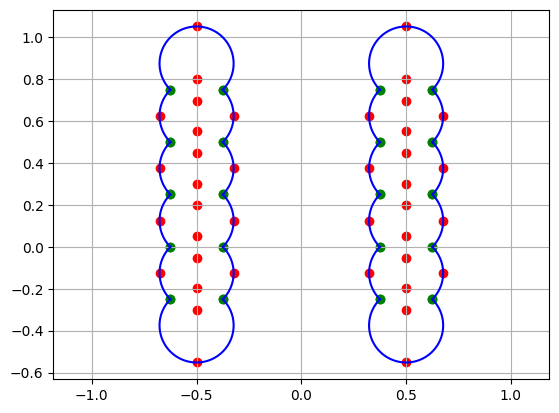

In [8]:
import matplotlib.pyplot as plt

# Simplify the obstacles.
obstacle_circles = np.array(
    [
        [
            problem.obstacle_positions[i][0],
            problem.obstacle_positions[i][1],
            problem.obstacle_radii[i],
        ]
        for i in range(problem.num_obstacles)
    ]
)

angles = circle_circle_intersection_angles(obstacle_circles, obstacle_circles)

# compute subdivisions
subdivisions = []
for i in range(len(obstacle_circles)):
    angles_here = angles[i, :, :2].flatten()
    angles_here = angles_here[~np.isnan(angles_here)]
    angles_here = np.mod(angles_here, 2 * np.pi)
    subdivisions.append(np.sort(angles_here))

new_pairs = []
for i in range(len(subdivisions)):
    for ta, tb in zip(
        subdivisions[i], [*subdivisions[i][1:], subdivisions[i][0] + 2 * np.pi]
    ):
        mid_angle = 0.5 * (ta + tb)
        mid_x = obstacle_circles[i][0] + obstacle_circles[i][2] * np.cos(mid_angle)
        mid_y = obstacle_circles[i][1] + obstacle_circles[i][2] * np.sin(mid_angle)
        plt.scatter([mid_x], [mid_y], color="red")
        plt.scatter(
            [obstacle_circles[i][0] + obstacle_circles[i][2] * np.cos(ta)],
            [obstacle_circles[i][1] + obstacle_circles[i][2] * np.sin(ta)],
            color="green",
        )

        # Check if the midpoint is inside any other obstacle
        distances = np.sqrt(
            (mid_x - obstacle_circles[:, 0]) ** 2
            + (mid_y - obstacle_circles[:, 1]) ** 2
        )
        ok = distances >= obstacle_circles[:, 2]
        ok[i] = True  # Ignore self
        if ok.all():
            new_pairs.append((i, ta, tb))

for i, ta, tb in new_pairs:
    circle = obstacle_circles[i]
    theta = np.linspace(ta, tb, 100)
    x = circle[0] + circle[2] * np.cos(theta)
    y = circle[1] + circle[2] * np.sin(theta)
    plt.plot(x, y, "b-")

plt.grid()
plt.axis("equal")
plt.show()


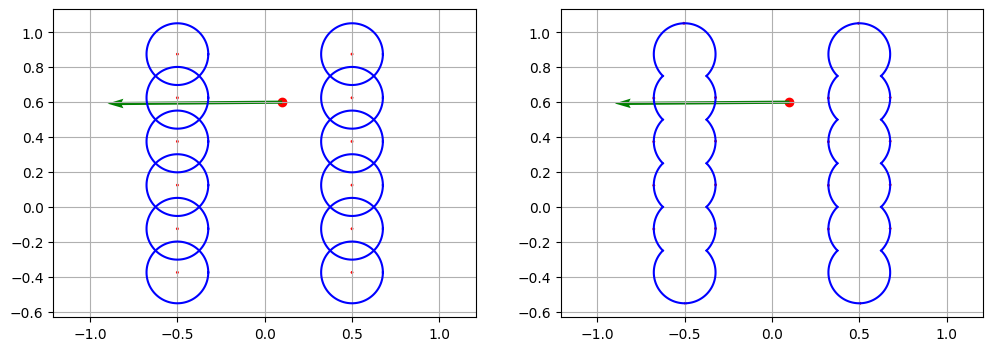

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

x = 0.1
y = 0.6
sigma = 0.1
overall_score_x = 0.0
overall_score_y = 0.0

plt.subplot(1, 2, 1)
plt.scatter([x], [y], color="red", label="Point of interest")

for i in range(len(obstacle_circles)):
    circle = obstacle_circles[i]
    theta = np.linspace(0, 2 * np.pi, 100)
    delta_x2 = circle[2] * np.cos(theta)
    delta_y2 = circle[2] * np.sin(theta)
    x2 = circle[0] + delta_x2
    y2 = circle[1] + delta_y2

    # draw score contribution from this arc
    dxy2 = np.sqrt((x2[1:] - x2[:-1]) ** 2 + (y2[1:] - y2[:-1]) ** 2)
    pdf2 = np.exp(-0.5 * ((x2 - x) ** 2 + (y2 - y) ** 2) / sigma**2)
    vec_x = np.sum(np.cos(theta[:-1]) * pdf2[:-1] * dxy2)
    vec_y = np.sum(np.sin(theta[:-1]) * pdf2[:-1] * dxy2)

    overall_score_x += vec_x
    overall_score_y += vec_y

    plt.quiver(
        circle[0],  # use the midpoint of the arc for the vector position
        circle[1],
        vec_x,
        vec_y,
        angles="xy",
        scale_units="xy",
        scale=1,
        color="red",
    )

    plt.plot(x2, y2, "b-")

mag = np.sqrt(overall_score_x**2 + overall_score_y**2)
plt.quiver(
    x,
    y,
    # overall_score_x,
    # overall_score_y,
    overall_score_x / mag,
    overall_score_y / mag,
    angles="xy",
    scale_units="xy",
    scale=1,
    color="green",
    label="Overall score vector",
)

plt.grid()
plt.axis("equal")

plt.subplot(1, 2, 2)
plt.scatter([x], [y], color="red", label="Point of interest")
overall_score_x = 0.0
overall_score_y = 0.0

for i, ta, tb in new_pairs:
    circle = obstacle_circles[i]
    theta = np.linspace(ta, tb, 100)
    delta_x2 = circle[2] * np.cos(theta)
    delta_y2 = circle[2] * np.sin(theta)
    x2 = circle[0] + delta_x2
    y2 = circle[1] + delta_y2

    # draw score contribution from this arc
    dxy2 = np.sqrt((x2[1:] - x2[:-1]) ** 2 + (y2[1:] - y2[:-1]) ** 2)
    pdf2 = np.exp(-0.5 * ((x2 - x) ** 2 + (y2 - y) ** 2) / sigma**2)
    vec_x = np.sum(np.cos(theta[:-1]) * pdf2[:-1] * dxy2)
    vec_y = np.sum(np.sin(theta[:-1]) * pdf2[:-1] * dxy2)

    overall_score_x += vec_x
    overall_score_y += vec_y

    plt.quiver(
        x2[len(theta) // 2],  # use the midpoint of the arc for the vector position
        y2[len(theta) // 2],
        vec_x,
        vec_y,
        angles="xy",
        scale_units="xy",
        scale=1,
        color="red",
    )

    plt.plot(x2, y2, "b-")

mag = np.sqrt(overall_score_x**2 + overall_score_y**2)

plt.quiver(
    x,
    y,
    overall_score_x / mag,
    overall_score_y / mag,
    angles="xy",
    scale_units="xy",
    scale=1,
    color="green",
    label="Overall score vector",
)
plt.axis("equal")
plt.grid()

plt.show()

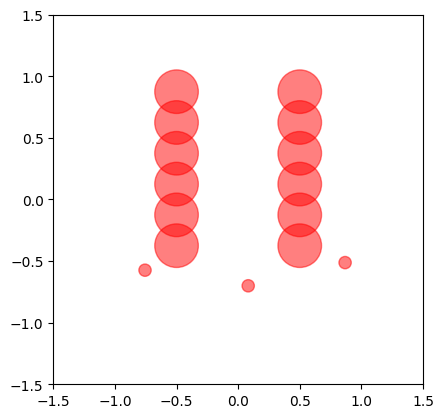

In [11]:
import matplotlib.pyplot as plt

trajectory = np.linspace(
    problem.agent_start_positions,
    problem.agent_end_positions,
    num=problem.num_timesteps,
)

# compute feasible region for first agent at timestep 0
other_circles = np.array(
    [
        [
            problem.obstacle_positions[i][0],
            problem.obstacle_positions[i][1],
            problem.obstacle_radii[i],
        ]
        for i in range(problem.num_obstacles)
    ]
    + [
        [trajectory[0, 1, 0], trajectory[0, 1, 1], problem.agent_radii[1]],
        [trajectory[0, 2, 0], trajectory[0, 2, 1], problem.agent_radii[2]],
    ]
    + [
        [trajectory[1, 0, 0], trajectory[1, 0, 1], problem.agent_max_speeds[0]],
    ]
)

# Plot the 'other circles'.
fig, ax = plt.subplots()
for circle in other_circles:
    circle_patch = plt.Circle((circle[0], circle[1]), circle[2], color="red", alpha=0.5)
    ax.add_patch(circle_patch)

plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

[[[-0.045     ]
  [-0.92352183]
  [-3.22352183]
  [-6.06647817]
  [-8.36647817]
  [-9.245     ]
  [-8.36647817]
  [-6.06647817]
  [-3.22352183]
  [-0.92352183]]]
[[3.39174199e+00 3.33066907e-16]] [0.72] [0.95599748] [[4.50346779]]
Computation time: 0.0006690025329589844


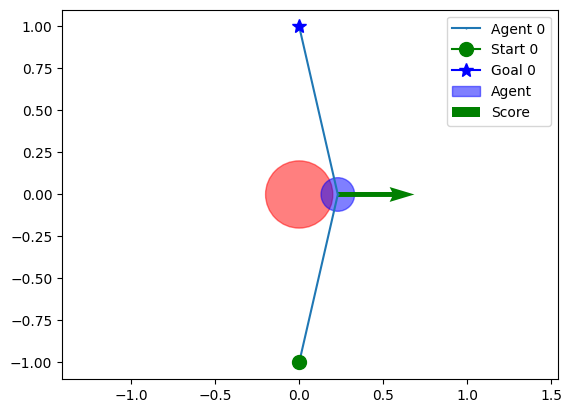

In [136]:
# Now, let's test whether we can successfully change variables to avoid the nonpenetration constraint violations when using the kinetic energy score. Again, we set up the simple test case.

from matplotlib.axes import Axes
from ael.score_function import (
    compute_feasibility_score_denominator,
    compute_feasibility_score_numerator,
)
import matplotlib.pyplot as plt
from ael.problem import Problem
from ael.visualize import visualize
import numpy as np


def show_result(problem: Problem, trajectory, sigma, score, agent_pos):
    # Plot the score.
    ax: Axes = plt.gca()
    visualize(problem, ax, trajectory)
    ax.add_patch(
        plt.Circle(
            (agent_pos[0, 0], agent_pos[0, 1]),
            sigma,
            color="blue",
            alpha=0.5,
            label="Agent",
        )
    )
    ax.quiver(
        agent_pos[:, 0],
        agent_pos[:, 1],
        score[:, 0],
        score[:, 1],
        scale=5.0,
        width=0.01,
        color="green",
        label="Score",
    )
    ax.axis("equal")
    ax.legend()
    plt.show()


def run(variable_x: float, sigma: float):
    problem = Problem[np.ndarray](
        num_timesteps=3,
        agent_start_positions=np.array([[0.0, -1.0]]),
        agent_end_positions=np.array([[0.0, 1.0]]),
        agent_reference_trajectory=None,
        agent_radii=np.array([0.05]),
        agent_max_speeds=np.array([0.05]),
        obstacle_positions=np.array([[0.0, 0.0]]),
        obstacle_radii=np.array([0.2]),
    )
    # (T, A, 2)
    trajectory = np.array([[[0.0, -1.0]], [[variable_x, 0.0]], [[0.0, 1.0]]])
    # (S, 6)
    surfaces = np.array(
        [
            [
                problem.obstacle_positions[0][0],
                problem.obstacle_positions[0][1],
                problem.obstacle_radii[0],
                0,
                2 * np.pi,
                1,
            ]
        ]
    )
    disks = np.array(
        [
            [
                problem.obstacle_positions[0][0],
                problem.obstacle_positions[0][1],
                problem.obstacle_radii[0],
                1,
            ]
        ]
    )

    import time

    t0 = time.time()
    agent_pos = trajectory[1, 0, :]
    feas_score_numerator, feas_score_numerator_exp_arg_max = (
        compute_feasibility_score_numerator(
            agent_pos[np.newaxis, :],
            sigma,
            surfaces,
            n_points=10,
        )
    )
    feas_score_denominator = compute_feasibility_score_denominator(
        agent_pos[np.newaxis, :],
        sigma,
        disks,
        n_samples=50,
    )
    # Compute fraction, with small constant to avoid divide-by-zero.
    # Note that the numerator should be rescaled by exp(exp_arg_min).
    # But since this number can be very low, we will lower bound it by eps.
    eps = 1e-12
    feas_score = (
        feas_score_numerator
        / (feas_score_denominator + eps)
        * np.maximum(np.exp(feas_score_numerator_exp_arg_max), eps)
    )

    max_score_mag = 1
    feas_score_mag = np.linalg.norm(feas_score, axis=-1, keepdims=True)
    feas_score_mag[feas_score_mag <= max_score_mag] = 1
    feas_score_mag[feas_score_mag > max_score_mag] = (
        feas_score_mag[feas_score_mag > max_score_mag] / max_score_mag
    )
    feas_score /= feas_score_mag
    print(
        feas_score_numerator,
        feas_score_denominator,
        np.maximum(np.exp(feas_score_numerator_exp_arg_max), eps),
        feas_score_mag,
    )

    score = 1 / (1 + sigma**2) * -trajectory[1, 0] + feas_score
    t1 = time.time()

    print("Computation time:", t1 - t0)
    show_result(problem, trajectory, sigma, score, agent_pos[np.newaxis, :])


run(variable_x=0.23, sigma=0.1)


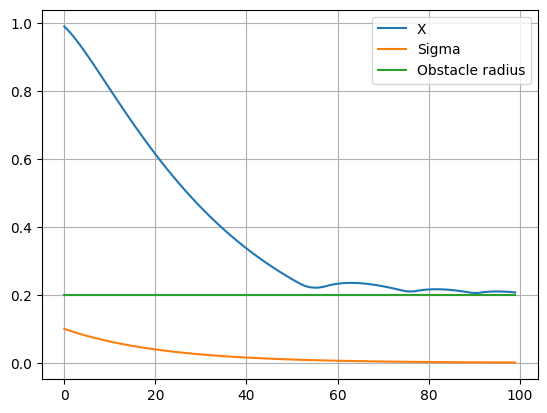

In [ ]:
# The next test will be to plot the x position of the agent throughout optimization. We can then compare what happens as sigma gets annealed.

import matplotlib.pyplot as plt
from ael.problem import Problem
import numpy as np


def run_2(variable_x: float, sigma: float):
    problem = Problem[np.ndarray](
        num_timesteps=3,
        agent_start_positions=np.array([[0.0, -1.0]]),
        agent_end_positions=np.array([[0.0, 1.0]]),
        agent_reference_trajectory=None,
        agent_radii=np.array([0.05]),
        agent_max_speeds=np.array([0.05]),
        obstacle_positions=np.array([[0.0, 0.0]]),
        obstacle_radii=np.array([0.2]),
    )
    # (T, A, 2)
    trajectory = np.array([[[0.0, -1.0]], [[variable_x, 0.0]], [[0.0, 1.0]]])
    # (S, 6)
    surfaces = np.array(
        [
            [
                problem.obstacle_positions[0][0],
                problem.obstacle_positions[0][1],
                problem.obstacle_radii[0],
                0,
                2 * np.pi,
                1,
            ]
        ]
    )
    disks = np.array(
        [
            [
                problem.obstacle_positions[0][0],
                problem.obstacle_positions[0][1],
                problem.obstacle_radii[0],
                1,
            ]
        ]
    )

    x_hist = []
    sigma_hist = []

    beta1 = 0.9
    beta2 = 0.999
    m = 0
    v = 0

    for logsigma in np.linspace(np.log(0.1), np.log(0.001), num=100):
        sigma = np.exp(logsigma)

        agent_pos = trajectory[1, 0, :]
        feas_score_numerator, feas_score_numerator_exp_arg_max = (
            compute_feasibility_score_numerator(
                agent_pos[np.newaxis, :],
                sigma,
                surfaces,
                n_points=5,
            )
        )
        feas_score_denominator = compute_feasibility_score_denominator(
            agent_pos[np.newaxis, :],
            sigma,
            disks,
            n_samples=50,
        )
        # Compute fraction, with small constant to avoid divide-by-zero.
        # Note that the numerator should be rescaled by exp(exp_arg_min).
        # But since this number can be very low, we will lower bound it by eps.
        eps = 1e-12
        feas_score = (
            feas_score_numerator
            / (feas_score_denominator + eps)
            * np.maximum(np.exp(feas_score_numerator_exp_arg_max), eps)
        )

        max_score_mag = 1
        feas_score_mag = np.linalg.norm(feas_score, axis=-1, keepdims=True)
        feas_score_mag[feas_score_mag <= max_score_mag] = 1
        feas_score_mag[feas_score_mag > max_score_mag] = (
            feas_score_mag[feas_score_mag > max_score_mag] / max_score_mag
        )
        feas_score /= feas_score_mag
        score = 1 / (1 + sigma**2) * -trajectory[1, 0] + feas_score

        m = beta1 * m + (1 - beta1) * score
        v = beta2 * v + (1 - beta2) * (score**2)
        m_hat = m / (1 - beta1)
        v_hat = v / (1 - beta2)
        trajectory[1, 0] += 0.01 * (m_hat / (np.sqrt(v_hat) + 1e-8))[0]

        x_hist.append(trajectory[1, 0, 0])
        sigma_hist.append(sigma)

    plt.plot(x_hist, label="X")
    plt.plot(sigma_hist, label="Sigma")
    plt.plot([problem.obstacle_radii[0]] * len(x_hist), label="Obstacle radius")
    plt.legend()
    plt.grid()
    plt.show()


run_2(variable_x=1.0, sigma=0.1)


/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_3146/26013647.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  score = pdf / erf_value


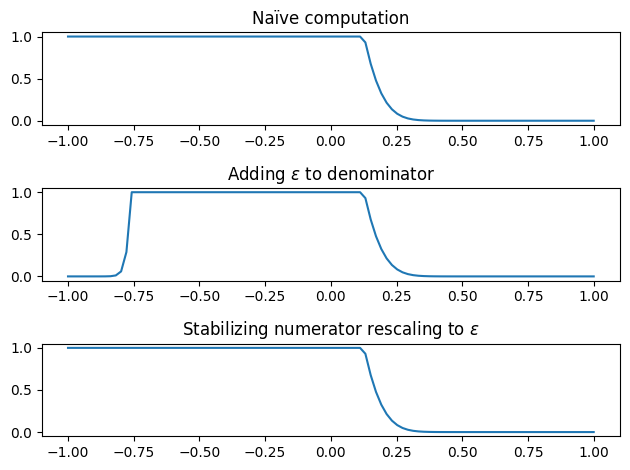

In [216]:
# Plotting various numerators and denominators, for Gaussian distributions against a constraint x ≥ 0.

import math

plt.subplot(3, 1, 1)
plt.title("Naïve computation")

xs = np.linspace(-1, 1, num=100)
scores = []
for x in xs:
    sigma = 0.1
    erf_value = 1 - math.erf(-x / sigma / np.sqrt(2))
    pdf = np.exp(-0.5 * (x**2) / sigma**2) / (np.sqrt(2 * np.pi) * sigma)
    score = pdf / erf_value
    score = min(score, 1)
    scores.append(score)

plt.plot(xs, scores)

plt.subplot(3, 1, 2)
plt.title("Adding $\\epsilon$ to denominator")

xs = np.linspace(-1, 1, num=100)
scores = []
for x in xs:
    sigma = 0.1
    erf_value = 1 - math.erf(-x / sigma / np.sqrt(2))
    pdf = np.exp(-0.5 * (x**2) / sigma**2) / (np.sqrt(2 * np.pi) * sigma)
    score = pdf / (erf_value + 1e-12)
    score = min(score, 1)
    scores.append(score)

plt.plot(xs, scores)

plt.subplot(3, 1, 3)
plt.title("Stabilizing numerator rescaling to $\\epsilon$")

xs = np.linspace(-1, 1, num=100)
scores = []
for x in xs:
    sigma = 0.1
    erf_value = 1 - math.erf(-x / sigma / np.sqrt(2))
    exp_arg = -0.5 * (x**2) / sigma**2
    exp_arg_max = exp_arg
    pdf = np.exp(exp_arg - exp_arg_max) / (np.sqrt(2 * np.pi) * sigma)
    score = pdf / (erf_value + 1e-12) * np.maximum(np.exp(exp_arg_max), 1e-12)
    score = min(score, 1)
    scores.append(score)

plt.plot(xs, scores)

plt.tight_layout()
plt.show()